<a href="https://colab.research.google.com/github/ponkpook/nlp_practical_2025_sEXism/blob/feat%2Fnlp-task1.1-1.2-1.3/nlp_total_task_ver2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install datasets scikit-learn pandas torch torchvision torchaudio numpy
# !pip uninstall -y transformers accelerate peft numpy
!pip install "transformers==4.39.3" "accelerate==0.30.0" "peft==0.10.0" "numpy==1.26.0"


  Using cached accelerate-0.30.0-py3-none-any.whl.metadata (19 kB)
  Using cached peft-0.10.0-py3-none-any.whl.metadata (13 kB)
Using cached accelerate-0.30.0-py3-none-any.whl (302 kB)
Using cached peft-0.10.0-py3-none-any.whl (199 kB)


In [ ]:
# ===============================================================
# 0. Dependencies  (install with: pip install -U numpy torch transformers datasets scikit-learn)
# ===============================================================
import ast
import json
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import accelerate
import transformers
from datasets import Dataset
from sklearn.metrics import accuracy_score, f1_score
from typing import Dict, Any, List, Tuple, Union, Optional
from transformers import (
    AutoModel,
    AutoTokenizer,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
    Trainer,
    TrainingArguments,
)
from google.colab import drive

drive.mount('/content/drive')
# 文件路径就是 /content/drive/MyDrive/你的文件夹/文件名
print("accelerate:", accelerate.__version__)
print("transformers:", transformers.__version__)
# df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/EXIST2025_cleaned_plus_AEDA_fullinfo.csv')



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
accelerate: 0.30.0
transformers: 4.39.3


In [ ]:
# ===============================================================
# 1. Global constants & hyper-parameters
# ===============================================================
CSV_PATH: str           = '/content/drive/MyDrive/Colab Notebooks/EXIST2025_cleaned_plus_AEDA_fullinfo.csv'
MODEL_NAME: str         = "vinai/bertweet-base"
MAX_LEN: int            = 128
BATCH_SIZE: int         = 64
EPOCHS: int             = 30
LR: float               = 2e-5
SEED: int               = 42

# Loss weights for three tasks
W1, W2, W3 = 1.0, 2.0, 3.0      # task-1, task-2, task-3 respectively

# Annotator categories --------------------------------------------------------
GENDER  = ["F", "M"]
AGE     = ["18-22", "23-45", "46+"]
ETHNIC  = [
    "White or Caucasian", "Black or African American", "Hispano or Latino",
    "Asian", "Middle Eastern", "Multiracial", "other"
]
G2I = {g: i for i, g in enumerate(GENDER)}
A2I = {a: i for i, a in enumerate(AGE)}
E2I = {e: i for i, e in enumerate(ETHNIC)}

TASK3_CLASSES: List[str] = [
    "IDEOLOGICAL-INEQUALITY",
    "STEREOTYPING-DOMINANCE",
    "OBJECTIFICATION",
    "SEXUAL-VIOLENCE",
    "MISOGYNY-NON-SEXUAL-VIOLENCE",
]
# -----------------------------------------------------------------------------

In [ ]:
# ===============================================================
# 2. Utility functions
# ===============================================================
def majority_yes(labels: List[str]) -> bool:
    """Return True if YES is the majority label among annotators."""
    return labels.count("YES") >= labels.count("NO")

def soft_label_task1(row: pd.Series) -> List[float]:
    return [0.0, 1.0] if majority_yes(ast.literal_eval(row["labels_task1_1"])) else [1.0, 0.0]


def soft_label_task2(row: pd.Series) -> List[float]:
    """4-way soft label: [DIRECT, REPORTED, JUDGEMENTAL, NO]."""
    if soft_label_task1(row)[1] == 0:   # NOT sexist
        return [0.0, 0.0, 0.0, 1.0]

    valid = [l for l in ast.literal_eval(row["labels_task1_2"])
             if l in {"DIRECT", "REPORTED", "JUDGEMENTAL"}]

    if not valid:
        return [0.0, 0.0, 0.0, 1.0]

    counts = np.array([
        valid.count("DIRECT"),
        valid.count("REPORTED"),
        valid.count("JUDGEMENTAL"),
    ], dtype=np.float32)
    probs = counts / counts.sum()
    return probs.tolist() + [0.0]        # NO class = 0 probability


def soft_label_task3(row: pd.Series) -> List[float]:
    """6-way soft label for multi-label task-3 (5 classes + NO)."""
    if soft_label_task1(row)[1] == 0:     # not sexist
        return [0.0] * 5 + [1.0]

    ann_lists = ast.literal_eval(row["labels_task1_3"])
    counter = np.zeros(len(TASK3_CLASSES), dtype=np.float32)

    for ann in ann_lists:
        for c in ann:
            if c in TASK3_CLASSES:
                counter[TASK3_CLASSES.index(c)] += 1

    if counter.sum() == 0:
        return [0.0] * 5 + [1.0]

    probs = counter / counter.sum()
    return probs.tolist() + [0.0]         # NO = 0 prob


def build_annot_vector(row: pd.Series) -> List[float]:
    genders = ast.literal_eval(row["gender_annotators"])
    ages    = ast.literal_eval(row["age_annotators"])
    ethnics = ast.literal_eval(row["ethnicities_annotators"])

    vec = np.zeros(len(GENDER) + len(AGE) + len(ETHNIC), dtype=np.float32)
    for g, a, e in zip(genders, ages, ethnics):
        vec[G2I.get(g, 0)] += 1
        vec[len(GENDER) + A2I.get(a, 0)] += 1
        vec[len(GENDER) + len(AGE) + E2I.get(e, "other")] += 1
    return (vec / len(genders)).tolist()


In [ ]:
# 3. Load & preprocess data
# ===============================================================
df = pd.read_csv(CSV_PATH)

# Keep English / Spanish rows with annotator info
df = df[df["lang"].isin(["en", "es"]) & df["labels_task1_1"].notnull()].copy()

df["soft_label_task1"] = df.apply(soft_label_task1, axis=1)
df["soft_label_task2"] = df.apply(soft_label_task2, axis=1)
df["soft_label_task3"] = df.apply(soft_label_task3, axis=1)
df["annot_vector"]     = df.apply(build_annot_vector, axis=1)
df.rename(columns={"text": "tweet"}, inplace=True)  # ensure column is named 'tweet'
df = df.loc[:, ~df.columns.duplicated()]


In [ ]:
# ===============================================================
# 4. Tokenisation & HF Dataset
# ===============================================================
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)


def tokenise(batch: Dict[str, List[str]]) -> Dict[str, List[List[int]]]:
    return tokenizer(batch["tweet"], padding="max_length", truncation=True, max_length=MAX_LEN)


dataset = Dataset.from_pandas(
    df[["tweet", "soft_label_task1", "soft_label_task2", "soft_label_task3", "annot_vector"]]
)
dataset = dataset.map(tokenise, batched=True, remove_columns=["tweet"])

train_ds, val_ds = dataset.train_test_split(test_size=0.1, seed=SEED).values()
tensor_cols = [
    "input_ids", "attention_mask",
    "soft_label_task1", "soft_label_task2", "soft_label_task3", "annot_vector"
]
train_ds.set_format("torch", columns=tensor_cols)
val_ds.set_format("torch", columns=tensor_cols)

# ===============================================================
# 5. Data collator
# ===============================================================
class MultiTaskCollator:
    def __init__(self, tok):
        self.base = DataCollatorWithPadding(tok, return_tensors="pt")

    def __call__(self, features):
        core = [{k: v for k, v in f.items() if k in ["input_ids", "attention_mask"]} for f in features]
        batch = self.base(core)

        def stack(key: str) -> torch.Tensor:
            return torch.stack([torch.tensor(f[key], dtype=torch.float32) for f in features])

        batch["soft_label_task1"] = stack("soft_label_task1")
        batch["soft_label_task2"] = stack("soft_label_task2")
        batch["soft_label_task3"] = stack("soft_label_task3")
        batch["annot_vector"]     = stack("annot_vector")
        return batch


collator = MultiTaskCollator(tokenizer)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/file_download.py:943: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
emoji is not installed, thus not converting emoticons or emojis into text. Install emoji: pip3 install emoji==0.6.0


Map:   0%|          | 0/10180 [00:00<?, ? examples/s]

In [ ]:
# ===============================================================
# 6. Model definition
# ===============================================================
class MultiTaskModel(nn.Module):
    """BERT-based encoder with three classification heads."""

    def __init__(self, base_model: str):
        super().__init__()
        self.encoder   = AutoModel.from_pretrained(base_model)
        hidden_size    = self.encoder.config.hidden_size

        # Annotator embedding  -> 16-d vector
        self.annot_fc  = nn.Linear(len(GENDER) + len(AGE) + len(ETHNIC), 16)

        # Classification heads
        self.cls_task1 = nn.Linear(hidden_size + 16, 2)
        self.cls_task2 = nn.Linear(hidden_size + 16, 4)
        self.cls_task3 = nn.Linear(hidden_size + 16, 6)   # 5 classes +

        self.dropout = nn.Dropout(0.2)

    def forward(
        self,
        input_ids: None,
        attention_mask: torch.Tensor,
        annot_vector: torch.Tensor,
        soft_label_task1=None,   # ← 新增
        soft_label_task2=None,   # ← 新增
        soft_label_task3=None,
    ) -> Dict[str, torch.Tensor]:
        enc_out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        cls_tok = enc_out.last_hidden_state[:, 0]                  # [B, H]
        pooled = self.dropout(cls_tok)
        annot_emb = self.annot_fc(annot_vector)                    # [B, 16]
        rep       = torch.cat([pooled, annot_emb], dim=1)         # [B, H+16]

        return {
            "logits_task1": self.cls_task1(rep),
            "logits_task2": self.cls_task2(rep),
            "logits_task3": self.cls_task3(rep),
        }


model = MultiTaskModel(MODEL_NAME)

# ===============================================================
# 7. Metric computation
# ===============================================================
def _sigmoid(x: np.ndarray) -> np.ndarray:
    return 1.0 / (1.0 + np.exp(-x))


def compute_metrics(
    eval_pred: Tuple[Tuple[np.ndarray, ...], Tuple[np.ndarray, ...]]
) -> Dict[str, float]:
    preds, labels = eval_pred              # unpack

    # ──────────────────────────
    # predictions
    logits1, logits2, logits3 = preds      # tuple → three arrays
    # labels may be a tuple or a dict depending on your collator.
    # If you collated (soft_label_task1, 2, 3) into a tuple, do:
    lbl1, lbl2, lbl3 = labels
    # Otherwise adapt accordingly.
    # ──────────────────────────

    metrics = {}

    # ---------- Task-1 (hard label) ----------
    y_pred1 = logits1.argmax(-1)
    y_true1 = lbl1.argmax(-1)              # assumes soft labels
    metrics.update(
        {
            "t1_acc": accuracy_score(y_true1, y_pred1),
            "t1_f1_macro": f1_score(y_true1, y_pred1, average="macro"),
            "t1_f1_weighted": f1_score(y_true1, y_pred1, average="weighted"),
        }
    )

    # ---------- Task-2 ----------
    y_pred2 = logits2.argmax(-1)
    y_true2 = lbl2.argmax(-1)
    metrics.update(
        {
            "t2_acc": accuracy_score(y_true2, y_pred2),
            "t2_f1_macro": f1_score(y_true2, y_pred2, average="macro"),
            "t2_f1_weighted": f1_score(y_true2, y_pred2, average="weighted"),
        }
    )

    # ---------- Task-3 (multi-label) ----------
    proba3  = 1 / (1 + np.exp(-logits3))   # sigmoid
    y_pred3 = (proba3 >= 0.25).astype(int)
    # y_true3 = (lbl3[:, :5] >= 0.5).astype(int)  # drop “NO” column if present
    y_true3 = (lbl3 >= 0.25).astype(int)           # no slicing
    metrics.update(
        {
            "t3_acc": accuracy_score(y_true3, y_pred3),
            "t3_f1_micro":    f1_score(y_true3, y_pred3, average="micro",   zero_division=0),
            "t3_f1_macro":    f1_score(y_true3, y_pred3, average="macro",   zero_division=0),
            "t3_f1_weighted": f1_score(y_true3, y_pred3, average="weighted",zero_division=0),
        }
    )

    return metrics


# ===============================================================
# 8. Custom Trainer (weighted multi-task loss)
# ===============================================================

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2, reduction='mean'):
        super().__init__()
        self.alpha = torch.tensor(alpha) if alpha else None
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        probs = torch.softmax(logits, dim=-1)
        log_probs = torch.log_softmax(logits, dim=-1)

        weight = (1 - probs) ** self.gamma
        focal = -weight * log_probs * targets

        if self.alpha is not None:
            alpha_weight = self.alpha.to(logits.device)
            focal = focal * alpha_weight

        loss = focal.sum(-1)  # sum over classes
        if self.reduction == "mean":
            return loss.mean()
        return loss

class MultiTaskTrainer(Trainer):

    # ---------- 5.1 ----------
    @staticmethod
    def hierarchical_postprocess(batch_logits):
        """
        接收 tuple 或 dict，
        强行把 task-2/3 的“不存在 YES 预测”位置 gate 成 NO one-hot，
        返回同结构的 tuple (logits1, logits2, logits3)
        """
        # --- logits ---
        if isinstance(batch_logits, dict):         # compute_loss(return_outputs=True)
            logits1 = batch_logits["logits_task1"]
            logits2 = batch_logits["logits_task2"]
            logits3 = batch_logits["logits_task3"]
        else:                                      # HF Trainer
            logits1, logits2, logits3 = batch_logits

        # --- gating ---
        NO2 = logits2.new_tensor([0, 0, 0, 1], dtype=logits2.dtype)
        NO3 = logits3.new_tensor([0, 0, 0, 0, 0, 1], dtype=logits3.dtype)

        pred1 = logits1.argmax(-1)          # 0 = NO, 1 = YES
        mask_no = pred1 == 0

        logits2 = logits2.clone()
        logits3 = logits3.clone()
        logits2[mask_no] = NO2
        logits3[mask_no] = NO3

        return (logits1, logits2, logits3)

    # ---------- 5.2 loss ----------
    def compute_loss(self, model, inputs, return_outputs=False):
        outputs = model(
            input_ids     = inputs["input_ids"],
            attention_mask= inputs["attention_mask"],
            annot_vector  = inputs["annot_vector"],
        )

        tgt1, tgt2, tgt3 = (inputs["soft_label_task1"],
                            inputs["soft_label_task2"],
                            inputs["soft_label_task3"])

        loss1 = F.kl_div(
            F.log_softmax(outputs["logits_task1"], dim=-1), tgt1, reduction="batchmean"
        )

        mask_yes = (tgt1[:, 1] > tgt1[:, 0]).float()          # YES=1,NO=0
        denom    = mask_yes.sum().clamp(min=1.)

        focal_fn = FocalLoss(alpha=[1, 2, 2, 1])
        kl_each = focal_fn(outputs["logits_task2"], tgt2)
        loss2 = (kl_each * mask_yes).sum() / denom

        bce_each = F.binary_cross_entropy_with_logits(
            outputs["logits_task3"], tgt3, reduction="none"
        ).mean(-1)
        loss3 = (bce_each * mask_yes).sum() / denom

        total = W1*loss1 + W2*loss2 + W3*loss3
        return (total, outputs) if return_outputs else total

    # ---------- 5.3 prediction_step ----------
    def prediction_step(
        self,
        model,
        inputs,
        prediction_loss_only: bool = False,
        ignore_keys=None,
    ):
        loss, outputs, labels = super().prediction_step(
            model, inputs, prediction_loss_only, ignore_keys
        )
        if prediction_loss_only or outputs is None:
            return loss, outputs, labels

        gated_logits = self.hierarchical_postprocess(outputs)
        return loss, gated_logits, labels

/usr/local/lib/python3.11/dist-packages/huggingface_hub/file_download.py:943: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [ ]:
# ===============================================================
# 9. Training
# ===============================================================
training_args = TrainingArguments(
    output_dir="./multitask_soft",
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    num_train_epochs=EPOCHS,
    learning_rate=LR,
    fp16=True,
    evaluation_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    metric_for_best_model="eval_loss",
    load_best_model_at_end=True,
    greater_is_better=False,
    seed=SEED,
    weight_decay=0.05,
    report_to=[],
)

trainer = MultiTaskTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    data_collator=collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)

if __name__ == "__main__":
    trainer.train()
    metrics = trainer.evaluate()
    pred_out = trainer.predict(val_ds)



/usr/local/lib/python3.11/dist-packages/accelerate/accelerator.py:446: FutureWarning: Passing the following arguments to `Accelerator` is deprecated and will be removed in version 1.0 of Accelerate: dict_keys(['dispatch_batches', 'split_batches', 'even_batches', 'use_seedable_sampler']). Please pass an `accelerate.DataLoaderConfiguration` instead: 
dataloader_config = DataLoaderConfiguration(dispatch_batches=None, split_batches=False, even_batches=True, use_seedable_sampler=True)
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/accelerate/accelerator.py:479: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)
/tmp/ipython-input-19-3932178801.py:36: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return tor

Epoch,Training Loss,Validation Loss,T1 Acc,T1 F1 Macro,T1 F1 Weighted,T2 Acc,T2 F1 Macro,T2 F1 Weighted,T3 Acc,T3 F1 Micro,T3 F1 Macro,T3 F1 Weighted
1,1.815300,2.965801,0.884086,0.883849,0.883932,0.725933,0.621645,0.741961,0.104126,0.383930,0.349602,0.478431
2,1.786400,3.076065,0.889980,0.889827,0.889762,0.768173,0.622484,0.759185,0.103143,0.391145,0.365543,0.489769
3,1.753000,2.907333,0.898821,0.898687,0.898745,0.717092,0.596746,0.729803,0.115914,0.392636,0.360075,0.489723
4,1.665400,3.003301,0.896857,0.896821,0.896790,0.753438,0.640506,0.756008,0.111002,0.393534,0.365498,0.492564
5,1.599500,3.146948,0.899804,0.899716,0.899763,0.752456,0.646016,0.763541,0.150295,0.400000,0.380065,0.497577
6,1.566100,3.159925,0.895874,0.895871,0.895861,0.712181,0.599072,0.717762,0.139489,0.404079,0.379678,0.500818


/tmp/ipython-input-19-3932178801.py:36: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.stack([torch.tensor(f[key], dtype=torch.float32) for f in features])
/tmp/ipython-input-19-3932178801.py:36: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.stack([torch.tensor(f[key], dtype=torch.float32) for f in features])
/tmp/ipython-input-19-3932178801.py:36: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.stack([torch.tensor(f[key], dtype=torch.float32) for f in features])
/tmp/ipython-input-19-3932178801.py:36: 

/tmp/ipython-input-19-3932178801.py:36: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.stack([torch.tensor(f[key], dtype=torch.float32) for f in features])


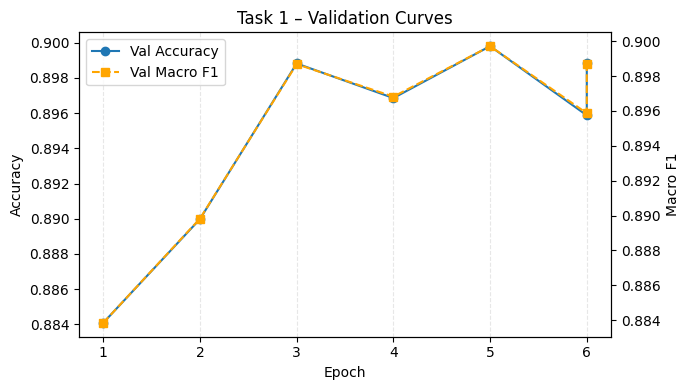

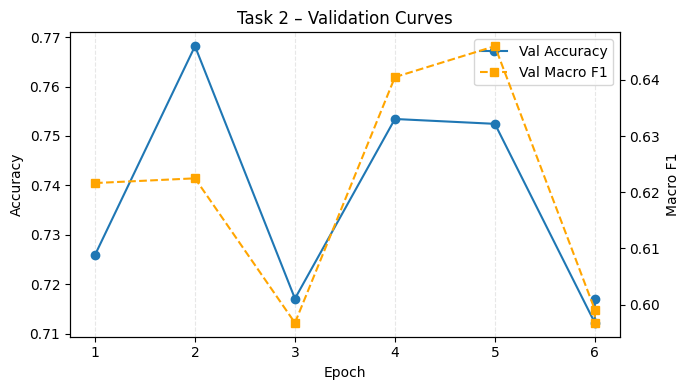

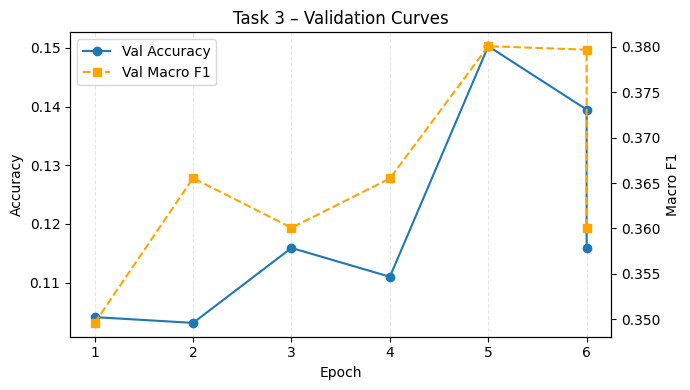

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------------------
# 确保 trainer 已经在内存里
# ----------------------------------------
trainer = globals().get("trainer")          # 如果是同一个 notebook 变量名通常就是 trainer
if trainer is None:
    raise RuntimeError(
        "找不到 `trainer` 变量，请在运行这段代码之前先完成训练，"
        "或者把 trainer 换成你自己的变量名。"
    )

# ----------------------------------------
# 1) 读取 log_history 中的验证记录
# ----------------------------------------
log_df   = pd.DataFrame(trainer.state.log_history)
eval_df  = log_df[log_df.eval_loss.notna()].copy()   # 只保留 evaluation 行
if eval_df.empty:
    raise ValueError("log_history 里没有 eval_* 指标，请确认 evaluation_strategy='epoch' 等设置正确。")

# ----------------------------------------
# 2) 定义各 Task 的指标列名
#    ▶ 如果 compute_metrics 返回的 key 不一样，请相应修改
# ----------------------------------------
tasks = {
    "Task 1": {"acc": "eval_t1_acc", "f1": "eval_t1_f1_macro"},
    "Task 2": {"acc": "eval_t2_acc", "f1": "eval_t2_f1_macro"},
    "Task 3": {"acc": "eval_t3_acc", "f1": "eval_t3_f1_micro"},
}

# ----------------------------------------
# 3) 逐个 Task 画双 y 轴曲线图
# ----------------------------------------
for task_name, keys in tasks.items():
    if not all(k in eval_df.columns for k in keys.values()):
        print(f"[跳过] {task_name}：日志中缺少 {keys}")
        continue

    fig, ax1 = plt.subplots(figsize=(7, 4))
    ax2 = ax1.twinx()

    # Accuracy —— 左 y 轴
    ax1.plot(eval_df["epoch"], eval_df[keys["acc"]],
             marker="o", linestyle="-", label="Val Accuracy")
    ax1.set_ylabel("Accuracy")
    ax1.set_xlabel("Epoch")
    ax1.grid(True, axis="x", linestyle="--", alpha=0.3)

    # Macro-F1 —— 右 y 轴
    ax2.plot(eval_df["epoch"], eval_df[keys["f1"]],
             marker="s", linestyle="--", color="orange", label="Val Macro F1")
    ax2.set_ylabel("Macro F1")

    # 合并图例
    lines, labels = [], []
    for ax in (ax1, ax2):
        lns, lbls = ax.get_legend_handles_labels()
        lines += lns
        labels += lbls
    ax1.legend(lines, labels, loc="best")

    plt.title(f"{task_name} – Validation Curves")
    plt.tight_layout()
    plt.show()

for task_name, keys in tasks.items():
    if not all(k in eval_df.columns for k in keys.values()):
        print(f"[跳过] {task_name}：日志中缺少 {keys}")
        continue
    if task_name != "Task 3":
        pass

    fig, ax1 = plt.subplots(figsize=(7, 4))
    ax2 = ax1.twinx()

    # Accuracy —— 左 y 轴
    ax1.plot(eval_df["epoch"], eval_df[keys["acc"]],
             marker="o", linestyle="-", label="Val Accuracy")
    ax1.set_ylabel("Accuracy")
    ax1.set_xlabel("Epoch")
    ax1.grid(True, axis="x", linestyle="--", alpha=0.3)

    # Macro-F1 —— 右 y 轴
    ax2.plot(eval_df["epoch"], eval_df[keys["f1"]],
             marker="s", linestyle="--", color="orange", label="Val Micro F1")
    ax2.set_ylabel("Micro F1")

    # 合并图例
    lines, labels = [], []
    for ax in (ax1, ax2):
        lns, lbls = ax.get_legend_handles_labels()
        lines += lns
        labels += lbls
    ax1.legend(lines, labels, loc="best")

    plt.title(f"{task_name} – Validation Curves")
    plt.tight_layout()
    plt.show()



/tmp/ipython-input-6-3932178801.py:36: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.stack([torch.tensor(f[key], dtype=torch.float32) for f in features])


Task1 宏平均F1=0.8879, Acc=0.8880, Precision=0.8886, Recall=0.8877
Task2 宏平均F1=0.5979, Acc=0.7102, Precision=0.6140, Recall=0.6184

Task1 分类报告：
              precision    recall  f1-score   support

          NO       0.90      0.87      0.88       501
         YES       0.88      0.91      0.89       517

    accuracy                           0.89      1018
   macro avg       0.89      0.89      0.89      1018
weighted avg       0.89      0.89      0.89      1018


Task2 分类报告：
              precision    recall  f1-score   support

      DIRECT       0.81      0.57      0.67       311
    REPORTED       0.53      0.52      0.52       123
 JUDGEMENTAL       0.23      0.51      0.31        83
          NO       0.89      0.88      0.88       501

    accuracy                           0.71      1018
   macro avg       0.61      0.62      0.60      1018
weighted avg       0.77      0.71      0.73      1018

Task1 混淆矩阵：
 [[435  66]
 [ 48 469]]
Task2 混淆矩阵：
 [[177  28  74  32]
 [  6  64  42  1

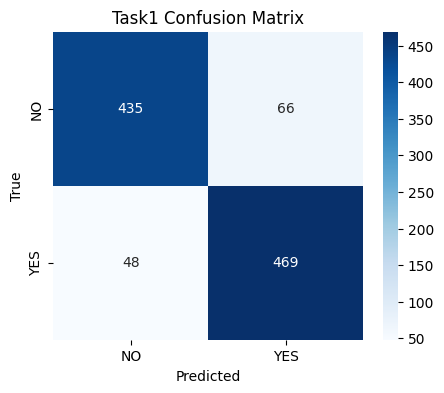

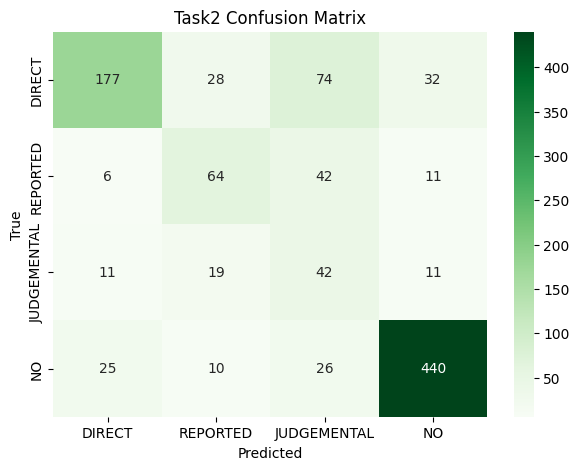

In [ ]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix
import numpy as np

# 用 Trainer 的 predict 方法获得 logits
eval_result = trainer.predict(val_ds)
logits_task1 = eval_result.predictions[0]  # [N, 2]
logits_task2 = eval_result.predictions[1]  # [N, 4]

# soft label => hard label（以最大概率类别为预测）
preds_task1 = np.argmax(logits_task1, axis=-1)
preds_task2 = np.argmax(logits_task2, axis=-1)

# 验证集真实标签
labels_task1 = np.array([np.argmax(x) for x in val_ds["soft_label_task1"]])
labels_task2 = np.array([np.argmax(x) for x in val_ds["soft_label_task2"]])

# task1 分类结果
acc1 = accuracy_score(labels_task1, preds_task1)
prec1, rec1, f1_1, _ = precision_recall_fscore_support(labels_task1, preds_task1, average='macro')
print(f"Task1 宏平均F1={f1_1:.4f}, Acc={acc1:.4f}, Precision={prec1:.4f}, Recall={rec1:.4f}")

# task2 分类结果
acc2 = accuracy_score(labels_task2, preds_task2)
prec2, rec2, f1_2, _ = precision_recall_fscore_support(labels_task2, preds_task2, average='macro')
print(f"Task2 宏平均F1={f1_2:.4f}, Acc={acc2:.4f}, Precision={prec2:.4f}, Recall={rec2:.4f}")

# 详细报告
print("\nTask1 分类报告：")
print(classification_report(labels_task1, preds_task1, target_names=["NO", "YES"]))

print("\nTask2 分类报告：")
print(classification_report(labels_task2, preds_task2, target_names=["DIRECT", "REPORTED", "JUDGEMENTAL", "NO"]))

# 可选：混淆矩阵
print("Task1 混淆矩阵：\n", confusion_matrix(labels_task1, preds_task1))
print("Task2 混淆矩阵：\n", confusion_matrix(labels_task2, preds_task2))

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# task1
labels_task1 = np.array([np.argmax(x) for x in val_ds["soft_label_task1"]])
preds_task1 = np.argmax(eval_result.predictions[0], axis=-1)
cm1 = confusion_matrix(labels_task1, preds_task1)

plt.figure(figsize=(5,4))
sns.heatmap(cm1, annot=True, fmt='d', cmap="Blues",
            xticklabels=["NO", "YES"], yticklabels=["NO", "YES"])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Task1 Confusion Matrix')
plt.show()

# task2
labels_task2 = np.array([np.argmax(x) for x in val_ds["soft_label_task2"]])
preds_task2 = np.argmax(eval_result.predictions[1], axis=-1)
cm2 = confusion_matrix(labels_task2, preds_task2)

plt.figure(figsize=(7,5))
sns.heatmap(cm2, annot=True, fmt='d', cmap="Greens",
            xticklabels=["DIRECT", "REPORTED", "JUDGEMENTAL", "NO"],
            yticklabels=["DIRECT", "REPORTED", "JUDGEMENTAL", "NO"])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Task2 Confusion Matrix')
plt.show()

/tmp/ipython-input-10-2391390437.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=labels_task1, palette="Blues")


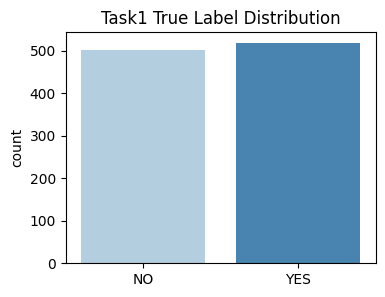

/tmp/ipython-input-10-2391390437.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=labels_task2, palette="Greens")


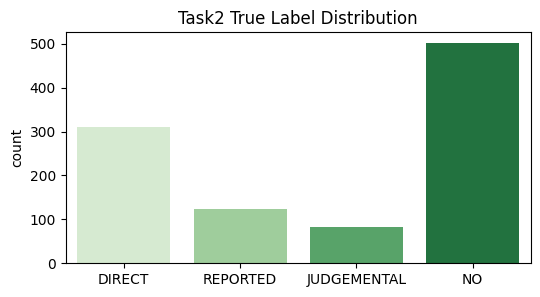

In [ ]:
# Task1
plt.figure(figsize=(4,3))
sns.countplot(x=labels_task1, palette="Blues")
plt.xticks([0,1], ["NO", "YES"])
plt.title("Task1 True Label Distribution")
plt.show()

# Task2
plt.figure(figsize=(6,3))
sns.countplot(x=labels_task2, palette="Greens")
plt.xticks([0,1,2,3], ["DIRECT", "REPORTED", "JUDGEMENTAL", "NO"])
plt.title("Task2 True Label Distribution")
plt.show()


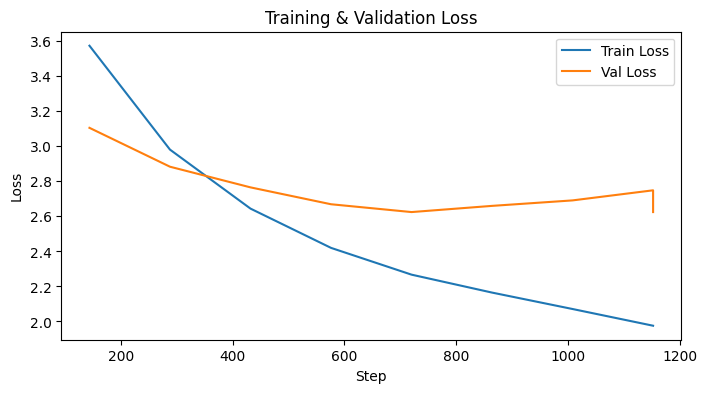

In [ ]:
import pandas as pd

logs = pd.DataFrame(trainer.state.log_history)
plt.figure(figsize=(8,4))
plt.plot(logs[logs['loss'].notnull()]['step'], logs[logs['loss'].notnull()]['loss'], label='Train Loss')
plt.plot(logs[logs['eval_loss'].notnull()]['step'], logs[logs['eval_loss'].notnull()]['eval_loss'], label='Val Loss')
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Training & Validation Loss")
plt.legend()
plt.show()

/tmp/ipython-input-6-3932178801.py:36: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.stack([torch.tensor(f[key], dtype=torch.float32) for f in features])


                              precision  recall  f1-score  support
IDEOLOGICAL-INEQUALITY            0.340   0.864     0.488    346.0
STEREOTYPING-DOMINANCE            0.377   0.997     0.548    380.0
OBJECTIFICATION                   0.327   0.864     0.475    337.0
SEXUAL-VIOLENCE                   0.156   0.448     0.231    201.0
MISOGYNY-NON-SEXUAL-VIOLENCE      0.231   0.506     0.317    312.0
NO                                0.901   0.868     0.884    501.0
micro avg                         0.366   0.795     0.501   2077.0
macro avg                         0.389   0.758     0.491   2077.0
weighted avg                      0.446   0.795     0.542   2077.0
samples avg                       0.445   0.833     0.492   2077.0


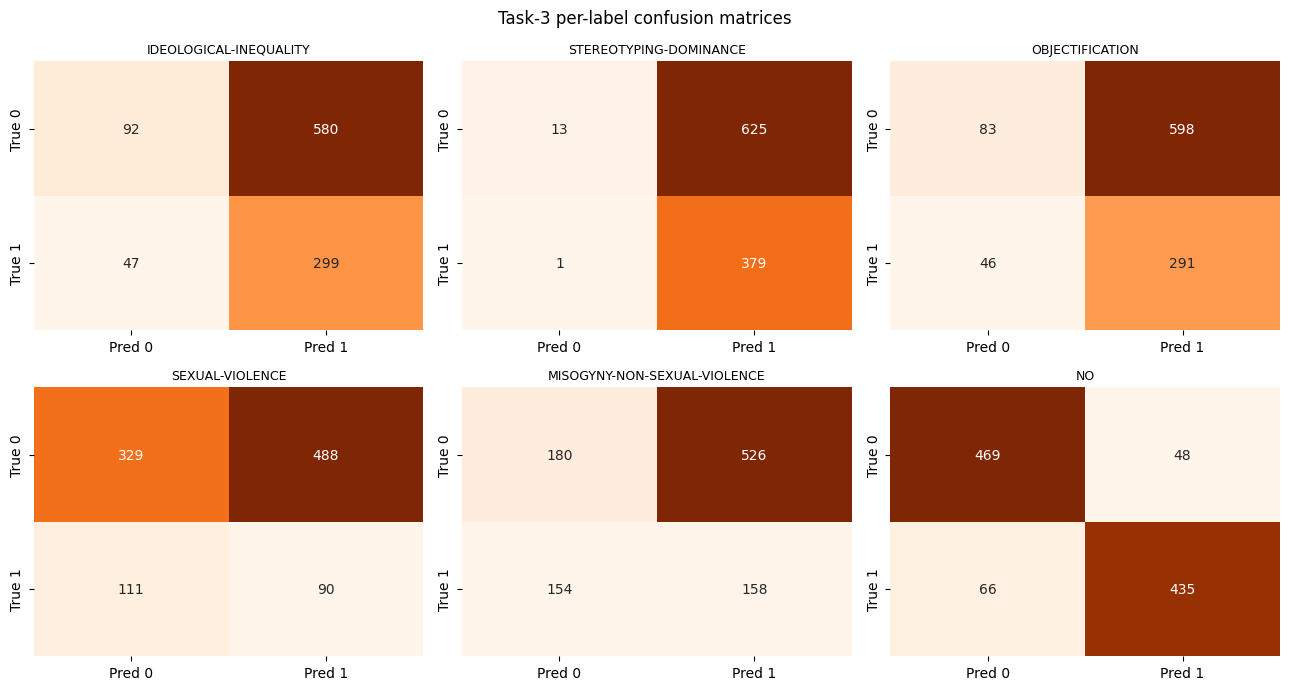

/tmp/ipython-input-12-4200171128.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=LABEL_NAMES_T3, y=vals, palette="mako")


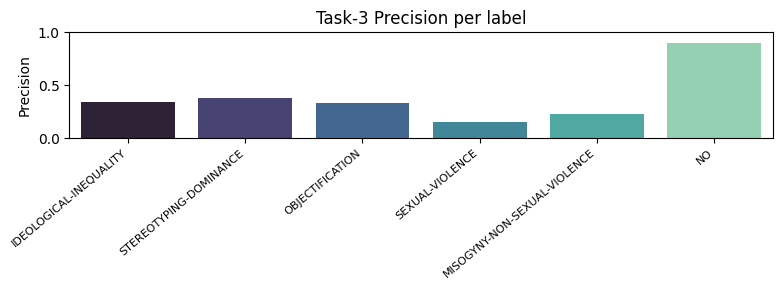

/tmp/ipython-input-12-4200171128.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=LABEL_NAMES_T3, y=vals, palette="mako")


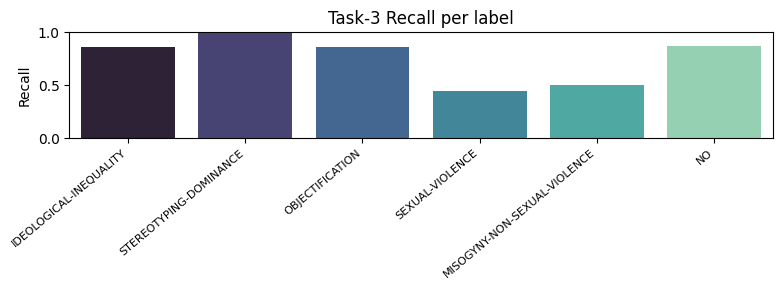

/tmp/ipython-input-12-4200171128.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=LABEL_NAMES_T3, y=vals, palette="mako")


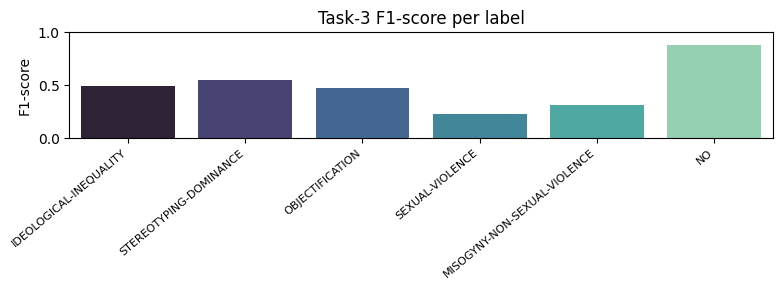

/tmp/ipython-input-12-4200171128.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=LABEL_NAMES_T3, y=pos_cnt, palette="rocket")


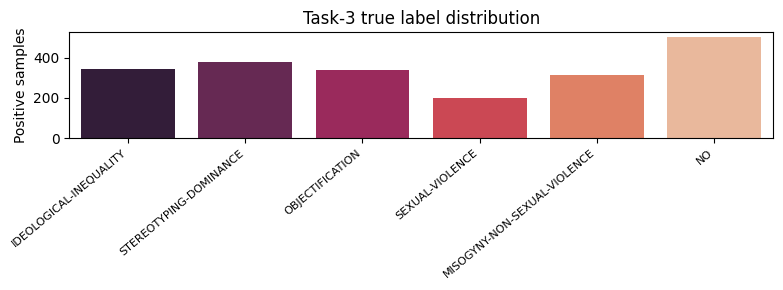

In [ ]:
# ======================================================================
#  Task-3  ——  多标签评估 + 可视化
# ======================================================================
from sklearn.metrics import classification_report, multilabel_confusion_matrix
import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt

eval_out = trainer.predict(val_ds)  # val_ds 是你的验证集

# ------------------ 1. 准备 y_true / y_pred ---------------------------
LOGITS_T3 = eval_out.predictions[2]               # [N, 6]  ← 你的 forward 第3个输出
LABEL_NAMES_T3 = [
    "IDEOLOGICAL-INEQUALITY",
    "STEREOTYPING-DOMINANCE",
    "OBJECTIFICATION",
    "SEXUAL-VIOLENCE",
    "MISOGYNY-NON-SEXUAL-VIOLENCE",
    "NO"
]

# y_true: 验证集的 soft-label 已经是 multi-hot 向量 (N,6)
y_true3 = np.array(val_ds["soft_label_task3"]) > 0        # bool 矩阵

# y_pred: logits → sigmoid 概率 → 阈值化
prob3   = 1 / (1 + np.exp(-LOGITS_T3))                    # sigmoid
thr_vec = np.array([0.1666]*6)                            # 统一阈值 / 自己调
y_pred3 = prob3 >= thr_vec                                # bool 矩阵

# ------------------ 2. sklearn classification report ------------------
report3 = classification_report(
    y_true3, y_pred3,
    target_names=LABEL_NAMES_T3,
    output_dict=True,
    zero_division=0
)
rep3_df = pd.DataFrame(report3).T
print(rep3_df.round(3))

# ------------------ 3. per-label 混淆矩阵 ------------------------------
ml_cm = multilabel_confusion_matrix(y_true3, y_pred3)     # shape (6, 2, 2)

fig, axes = plt.subplots(2, 3, figsize=(13,7))
for idx, ax in enumerate(axes.flat):
    sns.heatmap(
        ml_cm[idx], annot=True, fmt='d', cmap="Oranges",
        xticklabels=["Pred 0","Pred 1"],
        yticklabels=["True 0","True 1"],
        ax=ax, cbar=False
    )
    ax.set_title(LABEL_NAMES_T3[idx], fontsize=9)
plt.suptitle("Task-3 per-label confusion matrices")
plt.tight_layout();  plt.show()

# ------------------ 4. 条形图：precision / recall / F1 -----------------
metrics = ["precision", "recall", "f1-score"]
for m in metrics:
    plt.figure(figsize=(8,3))
    vals = [report3[lab][m] for lab in LABEL_NAMES_T3]
    sns.barplot(x=LABEL_NAMES_T3, y=vals, palette="mako")
    plt.xticks(rotation=40, ha='right', fontsize=8)
    plt.ylim(0,1); plt.ylabel(m.capitalize())
    plt.title(f"Task-3 {m.capitalize()} per label")
    plt.tight_layout(); plt.show()

# ------------------ 5. 标签分布条形图 -----------------
plt.figure(figsize=(8,3))
pos_cnt = y_true3.sum(axis=0)           # 每列正样本数
sns.barplot(x=LABEL_NAMES_T3, y=pos_cnt, palette="rocket")
plt.xticks(rotation=40, ha='right', fontsize=8)
plt.ylabel("Positive samples")
plt.title("Task-3 true label distribution")
plt.tight_layout(); plt.show()

In [ ]:
# ===============================================================
# 0. 依赖
# pip install -U numpy torch transformers datasets scikit-learn
# ===============================================================
import ast, json, numpy as np, pandas as pd, torch, torch.nn as nn
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from transformers import EarlyStoppingCallback
from transformers import (AutoTokenizer, Trainer, TrainingArguments,
                          DataCollatorWithPadding, AutoModel)
from datasets import Dataset
# -----------------------------
CSV_PATH = "/content/EXIST2025_cleaned_plus_AEDA_fullinfo.csv"
MODEL_NAME = "vinai/bertweet-base"
MAX_LEN = 128
W1, W2, W3 = 0.7, 1.3, 2.0
# ===============================================================
# 1. 读 csv 并构造软标签
# ---------------------------------------------------------------
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/EXIST2025_cleaned_plus_AEDA_fullinfo.csv')

# ---- 1.1 只要 en / es 并且 annotator 标注存在 ----
df = df[df["lang"].isin(["en", "es"]) & df["labels_task1_1"].notnull()].copy()

def make_soft_task1(row):
    # >3 YES 归为 [0,1]；否则 [1,0]
    labels = ast.literal_eval(row["labels_task1_1"])
    yes = labels.count("YES")
    no  = labels.count("NO")
    return [0., 1.] if yes > no else [1., 0.]

def make_soft_task2(row):
    # 只对 task1 被判 YES 的 annotator 才算，"-" 忽略
    if make_soft_task1(row)[1] == 0:      # task1=>NO
        return [0.,0.,0.,1.]              # NO 类独占概率 1
    ints = [l for l in ast.literal_eval(row["labels_task1_2"])
            if l in ["DIRECT","REPORTED","JUDGEMENTAL"]]
    if not ints:
        return [0.,0.,0.,1.]
    p = [ints.count("DIRECT"),
         ints.count("REPORTED"),
         ints.count("JUDGEMENTAL")]
    p = np.asarray(p, dtype=np.float32)
    p = p / p.sum()
    return p.tolist() + [0.]              # add dummy “NO”=0 概率

T3_CATS = [
    "IDEOLOGICAL-INEQUALITY",
    "STEREOTYPING-DOMINANCE",
    "OBJECTIFICATION",
    "SEXUAL-VIOLENCE",
    "MISOGYNY-NON-SEXUAL-VIOLENCE",
]                                   # len = 5,  最后会再加一个 “NO”

def make_soft_task3(row):
    # 如果 task1 判定为 NOT-sexist → [0,0,0,0,0,1]
    if make_soft_task1(row)[1] == 0:
        return [0., 0., 0., 0., 0., 1.]

    # 统计 6 位 annotator 各自选了哪些子类
    ann_lists = ast.literal_eval(row["labels_task1_3"])  # -> list[list[str]]
    counter = np.zeros(len(T3_CATS), dtype=np.float32)

    for ann in ann_lists:
        for c in ann:
            if c in T3_CATS:
                counter[T3_CATS.index(c)] += 1

    if counter.sum() == 0:                          # 全部是 "-" 或 "UNKNOWN"
        return [0., 0., 0., 0., 0., 1.]

    probs = counter / counter.sum()                 # 归一化
    return probs.tolist() + [0.]                    # 末尾再加 1 个 “NO” 概率 0

df["soft_label_task3"] = df.apply(make_soft_task3, axis=1)

df["soft_label_task1"] = df.apply(make_soft_task1, axis=1)
df["soft_label_task2"] = df.apply(make_soft_task2, axis=1)

# ===============================================================
# 2. 计算 annotator one-hot→dense 向量
# ---------------------------------------------------------------
gender_vals = ["F", "M"]
age_vals    = ["18-22", "23-45", "46+"]
eth_vals    = ["White or Caucasian","Black or African American","Hispano or Latino",
               "Asian","Middle Eastern","Multiracial","other"]
g2i = {v:i for i,v in enumerate(gender_vals)}
a2i = {v:i for i,v in enumerate(age_vals)}
e2i = {v:i for i,v in enumerate(eth_vals)}

def build_annot_vec(ex):
    g = ast.literal_eval(ex["gender_annotators"])
    a = ast.literal_eval(ex["age_annotators"])
    e = ast.literal_eval(ex["ethnicities_annotators"])
    v = np.zeros(len(gender_vals)+len(age_vals)+len(eth_vals), dtype=np.float32)
    for gg,aa,ee in zip(g,a,e):
        v[g2i.get(gg,0)] += 1
        v[len(gender_vals)+a2i.get(aa,0)] += 1
        v[len(gender_vals)+len(age_vals)+e2i.get(ee,"other")] += 1
    v = v / len(g)          # 6 annotators →平均
    return v.tolist()

df["annot_vector"] = df.apply(build_annot_vec, axis=1)

# ===============================================================
# 3. HuggingFace Dataset + tokenizer
# ---------------------------------------------------------------
tok = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)

def tokenize(batch):
    return tok(batch["text"], padding="max_length", truncation=True,
               max_length=MAX_LEN)

ds = Dataset.from_pandas(df[["text","soft_label_task1","soft_label_task2","soft_label_task3", "annot_vector"]])
ds = ds.map(tokenize, batched=True, remove_columns=["text"])

train_ds, val_ds = ds.train_test_split(test_size=0.1, seed=42).values()

# set_format 只保留需要 tensor 化的列
cols = [
    "input_ids", "attention_mask",
    "soft_label_task1", "soft_label_task2", "soft_label_task3",
    "annot_vector"
]
train_ds.set_format("torch", columns=cols)
val_ds.set_format("torch",   columns=cols)
print(train_ds.column_names)
print(train_ds[0].keys())          # 第 0 条样本应包含 soft_label_task1

missing = [i for i,x in enumerate(train_ds) if "soft_label_task1" not in x]
print("num missing =", len(missing))   # 应该是 0

# ===============================================================
# 4. DataCollator —— 把 list → tensor，并喂给模型
# ---------------------------------------------------------------
class Collator:
    def __init__(self):
        self.base = DataCollatorWithPadding(tok, return_tensors="pt")

    def __call__(self, features):
        batch = self.base([{k: v for k, v in f.items()
                            if k in ["input_ids", "attention_mask"]}
                           for f in features])

        def stack(key):                          # 小工具
            return torch.stack([torch.as_tensor(f[key], dtype=torch.float32)
                                for f in features])

        batch["soft_label_task1"] = stack("soft_label_task1")
        batch["soft_label_task2"] = stack("soft_label_task2")
        batch["soft_label_task3"] = stack("soft_label_task3")   # ← 新增
        batch["annot_vector"]     = stack("annot_vector")
        return batch

collator = Collator()

# ===============================================================
# 5. 多任务模型
# ---------------------------------------------------------------
class MultiTaskModel(nn.Module):
    def __init__(self, model_name):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        h = self.encoder.config.hidden_size
        self.annot_fc = nn.Linear(len(gender_vals)+len(age_vals)+len(eth_vals), 16)
        self.class1   = nn.Linear(h+16, 2)
        self.class2   = nn.Linear(h+16, 4)
        self.class3 = nn.Linear(h+16, 6)  # num_labels_task3 = 5
    def forward(
        self,
        input_ids=None,
        attention_mask=None,
        annot_vector=None,
        soft_label_task1=None,   # ← 新增
        soft_label_task2=None,   # ← 新增
        soft_label_task3=None,   # ← 新增
    ):  # **kwargs 防止意外键
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        cls = out.last_hidden_state[:,0]        # [B,h]
        if annot_vector is not None:
            ann = self.annot_fc(annot_vector)
            rep = torch.cat([cls, ann], dim=1)
        else:
            rep = cls
        logits_task1 = self.class1(rep)
        logits_task2 = self.class2(rep)
        logits_task3 = self.class3(rep)          # 新增 Task 1.3 的输出
        return {
            'logits_task1': logits_task1,
            'logits_task2': logits_task2,
            'logits_task3': logits_task3
        }

model = MultiTaskModel(MODEL_NAME)

def _sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

def compute_metrics(eval_pred):
    """
    eval_pred 由 Trainer 传入，通常是 (preds, labels)：
      ▸ preds  可以是 tuple / dict / ndarray（取决于 model.forward 返回）
      ▸ labels 从数据集里来，这里依旧用 val_ds 里的软标签做 “真值”
    """
    logits, _ = eval_pred        # labels 不直接用，真值从 val_ds 里拿软标签→硬标签

    # -------- 1. 拆分三套 logits --------
    logits1 = logits2 = logits3 = None

    if isinstance(logits, tuple):           # forward 返回 tuple
        if len(logits) == 3:                # (logits1, logits2, logits3)
            logits1, logits2, logits3 = logits
        elif len(logits) == 2:              # (logits1, logits2)
            logits1, logits2 = logits
    elif isinstance(logits, dict):          # forward 返回 dict
        logits1 = logits["logits_task1"]
        logits2 = logits.get("logits_task2")
        logits3 = logits.get("logits_task3")
    else:                                   # 单一输出
        logits1 = logits                    # 只 Task1

    metrics = {}

    # -------- 2. Task-1（二分类） --------
    if logits1 is not None:
        y_pred1 = np.argmax(logits1, axis=-1)
        y_true1 = np.argmax(val_ds["soft_label_task1"], axis=-1)      # 硬标签
        metrics.update({
            "t1_acc"        : accuracy_score(y_true1, y_pred1),
            "t1_f1_macro"   : f1_score(y_true1, y_pred1, average="macro"),
            "t1_f1_weighted": f1_score(y_true1, y_pred1, average="weighted"),
        })

    # -------- 3. Task-2（四分类） --------
    if logits2 is not None:
        y_pred2 = np.argmax(logits2, axis=-1)
        y_true2 = np.argmax(val_ds["soft_label_task2"], axis=-1)
        metrics.update({
            "t2_acc"        : accuracy_score(y_true2, y_pred2),
            "t2_f1_macro"   : f1_score(y_true2, y_pred2, average="macro"),
            "t2_f1_weighted": f1_score(y_true2, y_pred2, average="weighted"),
        })

    # -------- 4. Task-3（五标签多标签） --------
    if logits3 is not None:
        # 1) 把 logits 过 sigmoid → 概率
        proba3   = _sigmoid(logits3)

        # 2) 设阈值（0.5 最常见，也可以用验证集调优）
        y_pred3  = (proba3 >= 0.5).astype(int)      # shape (B, 5)

        # 3) 软标签 → 硬标签（>=0.5 视为被选中）
        y_true3 = (val_ds["soft_label_task3"].numpy() >= 0.5).astype(int)

        # 4) 多标签 F1：
        metrics.update({
            "t3_acc"        : accuracy_score(y_true3, y_pred3),
            "t3_f1_micro" : f1_score(y_true3, y_pred3, average="micro", zero_division=0),
            "t3_f1_macro" : f1_score(y_true3, y_pred3, average="macro", zero_division=0),
            "t3_f1_weight": f1_score(y_true3, y_pred3, average="weighted", zero_division=0),
        })

    return metrics

# ===============================================================
# 6. 自定义 Trainer 只写 compute_loss
# ---------------------------------------------------------------
def kl(logits, target, T=3):
    return F.kl_div(F.log_softmax(logits/T,-1), target, reduction="batchmean")*(T**2)
class MTTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False):
        # ------- 1. 前向传播 -------
        outputs = model(
            input_ids      = inputs["input_ids"],
            attention_mask = inputs["attention_mask"],
            annot_vector   = inputs["annot_vector"],
        )                                # 得到 3 个 logits

        # ------- 2. 取目标（软）标签 -------
        tgt1 = inputs["soft_label_task1"]      # shape: (B, 2)
        tgt2 = inputs["soft_label_task2"]      # shape: (B, 4)
        tgt3 = inputs["soft_label_task3"]      # shape: (B, 5)  — 多标签

        # ------- 3. 分别计算每个任务的损失 -------
        # Task 1 / Task 2 用 KL 散度（软标签 → softmax）
        loss1 = F.kl_div(
            F.log_softmax(outputs["logits_task1"], dim=-1), tgt1,
            reduction="batchmean"
        )
        loss2 = F.kl_div(
            F.log_softmax(outputs["logits_task2"], dim=-1), tgt2,
            reduction="batchmean"
        )

        # Task 3 是多标签 → 用 BCE-with-logits
        loss3 = F.binary_cross_entropy_with_logits(
            outputs["logits_task3"], tgt3
        )

        # ------- 4. 可选：若 tweet 判定为非性别歧视 (Task1=NO)，不计入 task2/3 损失 -------
        # mask_yes = tgt1[:, 1] > 0           # “YES” 这一列的概率 > 0 视为正样本
        # loss2 = (loss2 * mask_yes).mean()
        # loss3 = (loss3 * mask_yes).mean()

        # ------- 5. 按权重加权 -------
        total_loss = W1 * loss1 + W2 * loss2 + W3 * loss3  # 例：自己设权重
        # 也可写成 total_loss = a*loss1 + b*loss2 + c*loss3

        return (total_loss, outputs) if return_outputs else total_loss

df['hard_t2'] = df['soft_label_task2'].apply(lambda x: np.argmax(x))
print(df['hard_t2'].value_counts())

# ===============================================================
# 7. 训练
# ---------------------------------------------------------------
args = TrainingArguments(
    output_dir="./multitask_soft",
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    num_train_epochs=30,
    learning_rate=2e-5,
    fp16=True,
    evaluation_strategy="epoch",   # 保存和评估都按 epoch
    save_strategy="epoch",         # 新增
    logging_strategy="epoch",
    report_to=[],
    metric_for_best_model="eval_loss",
    load_best_model_at_end=True,
    greater_is_better=False,
    seed=42,
)

trainer = MTTrainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    data_collator=collator,
    compute_metrics=compute_metrics,  # 这里才是
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)

trainer.train()

/usr/local/lib/python3.11/dist-packages/huggingface_hub/file_download.py:943: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
emoji is not installed, thus not converting emoticons or emojis into text. Install emoji: pip3 install emoji==0.6.0


Map:   0%|          | 0/10180 [00:00<?, ? examples/s]

['soft_label_task1', 'soft_label_task2', 'soft_label_task3', 'annot_vector', 'input_ids', 'token_type_ids', 'attention_mask']
dict_keys(['soft_label_task1', 'soft_label_task2', 'soft_label_task3', 'annot_vector', 'input_ids', 'attention_mask'])
num missing = 0


/usr/local/lib/python3.11/dist-packages/huggingface_hub/file_download.py:943: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


hard_t2
3    6346
0    2314
1     925
2     595
Name: count, dtype: int64


/usr/local/lib/python3.11/dist-packages/accelerate/accelerator.py:446: FutureWarning: Passing the following arguments to `Accelerator` is deprecated and will be removed in version 1.0 of Accelerate: dict_keys(['dispatch_batches', 'split_batches', 'even_batches', 'use_seedable_sampler']). Please pass an `accelerate.DataLoaderConfiguration` instead: 
dataloader_config = DataLoaderConfiguration(dispatch_batches=None, split_batches=False, even_batches=True, use_seedable_sampler=True)
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/accelerate/accelerator.py:479: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)


Epoch,Training Loss,Validation Loss,T1 Acc,T1 F1 Macro,T1 F1 Weighted,T2 Acc,T2 F1 Macro,T2 F1 Weighted,T3 Acc,T3 F1 Micro,T3 F1 Macro,T3 F1 Weight
1,2.113900,1.778230,0.777014,0.757467,0.774782,0.689587,0.347266,0.628542,0.634578,0.698113,0.138785,0.593328
2,1.705200,1.695649,0.789784,0.785964,0.793155,0.708251,0.488595,0.706849,0.590373,0.673699,0.137053,0.585924
3,1.419200,1.567796,0.837917,0.831067,0.839622,0.731827,0.517622,0.732953,0.641454,0.717083,0.144608,0.618223
4,1.212600,1.524064,0.849705,0.838242,0.849071,0.760314,0.526323,0.744806,0.666994,0.735825,0.146976,0.628345
5,1.053900,1.458639,0.862475,0.853498,0.862618,0.769155,0.540619,0.759258,0.667976,0.738845,0.148119,0.633233
6,0.930200,1.556686,0.869352,0.863252,0.870515,0.753438,0.471326,0.732456,0.663065,0.739451,0.148867,0.636433
7,0.836800,1.444270,0.872299,0.866394,0.873457,0.775049,0.573791,0.776781,0.660118,0.740094,0.149080,0.637342
8,0.785800,1.397626,0.883104,0.874880,0.882947,0.790766,0.577927,0.784781,0.685658,0.755208,0.151160,0.646233
9,0.700700,1.425700,0.889980,0.883843,0.890557,0.790766,0.602389,0.793043,0.684676,0.757114,0.157649,0.651606
10,0.658000,1.475082,0.888016,0.883137,0.889142,0.763261,0.571916,0.777203,0.672888,0.748327,0.165627,0.651015


TrainOutput(global_step=2016, training_loss=0.975711428929889, metrics={'train_runtime': 1073.6075, 'train_samples_per_second': 256.015, 'train_steps_per_second': 4.024, 'total_flos': 0.0, 'train_loss': 0.975711428929889, 'epoch': 14.0})

In [ ]:
# # ===============================================================
# # 0. Dependencies  (install with: pip install -U numpy torch transformers datasets scikit-learn)
# # ===============================================================
# import ast
# import json
# from pathlib import Path
# from typing import Dict, List, Tuple

# import numpy as np
# import pandas as pd
# import torch
# import torch.nn as nn
# import torch.nn.functional as F
# from datasets import Dataset
# from sklearn.metrics import accuracy_score, f1_score
# from transformers import (
#     AutoModel,
#     AutoTokenizer,
#     DataCollatorWithPadding,
#     EarlyStoppingCallback,
#     Trainer,
#     TrainingArguments,
# )

# # ===============================================================
# # 1. Global constants & hyper-parameters
# # ===============================================================
# CSV_PATH: str           = '/content/drive/MyDrive/Colab Notebooks/EXIST2025_cleaned_plus_AEDA_fullinfo.csv'
# MODEL_NAME: str         = "vinai/bertweet-base"
# MAX_LEN: int            = 128
# BATCH_SIZE: int         = 64
# EPOCHS: int             = 3
# LR: float               = 2e-5
# SEED: int               = 42

# # Loss weights for three tasks
# W1, W2, W3 = 0.7, 1.3, 2.0      # task-1, task-2, task-3 respectively

# # Annotator categories --------------------------------------------------------
# GENDER  = ["F", "M"]
# AGE     = ["18-22", "23-45", "46+"]
# ETHNIC  = [
#     "White or Caucasian", "Black or African American", "Hispano or Latino",
#     "Asian", "Middle Eastern", "Multiracial", "other"
# ]
# G2I = {g: i for i, g in enumerate(GENDER)}
# A2I = {a: i for i, a in enumerate(AGE)}
# E2I = {e: i for i, e in enumerate(ETHNIC)}

# TASK3_CLASSES: List[str] = [
#     "IDEOLOGICAL-INEQUALITY",
#     "STEREOTYPING-DOMINANCE",
#     "OBJECTIFICATION",
#     "SEXUAL-VIOLENCE",
#     "MISOGYNY-NON-SEXUAL-VIOLENCE",
# ]
# # -----------------------------------------------------------------------------


# # ===============================================================
# # 2. Utility functions
# # ===============================================================
# def majority_yes(labels: List[str]) -> bool:
#     """Return True if YES is the majority label among annotators."""
#     return labels.count("YES") >= labels.count("NO")


# def soft_label_task1(row: pd.Series) -> List[float]:
#     return [0.0, 1.0] if majority_yes(ast.literal_eval(row["labels_task1_1"])) else [1.0, 0.0]


# def soft_label_task2(row: pd.Series) -> List[float]:
#     """4-way soft label: [DIRECT, REPORTED, JUDGEMENTAL, NO]."""
#     if soft_label_task1(row)[1] == 0:   # NOT sexist
#         return [0.0, 0.0, 0.0, 1.0]

#     valid = [l for l in ast.literal_eval(row["labels_task1_2"])
#              if l in {"DIRECT", "REPORTED", "JUDGEMENTAL"}]

#     if not valid:
#         return [0.0, 0.0, 0.0, 1.0]

#     counts = np.array([
#         valid.count("DIRECT"),
#         valid.count("REPORTED"),
#         valid.count("JUDGEMENTAL"),
#     ], dtype=np.float32)
#     probs = counts / counts.sum()
#     return probs.tolist() + [0.0]        # NO class = 0 probability


# def soft_label_task3(row: pd.Series) -> List[float]:
#     """6-way soft label for multi-label task-3 (5 classes + NO)."""
#     if soft_label_task1(row)[1] == 0:     # not sexist
#         return [0.0] * 5 + [1.0]

#     ann_lists = ast.literal_eval(row["labels_task1_3"])
#     counter = np.zeros(len(TASK3_CLASSES), dtype=np.float32)

#     for ann in ann_lists:
#         for c in ann:
#             if c in TASK3_CLASSES:
#                 counter[TASK3_CLASSES.index(c)] += 1

#     if counter.sum() == 0:
#         return [0.0] * 5 + [1.0]

#     probs = counter / counter.sum()
#     return probs.tolist() + [0.0]         # NO = 0 prob


# def build_annot_vector(row: pd.Series) -> List[float]:
#     genders = ast.literal_eval(row["gender_annotators"])
#     ages    = ast.literal_eval(row["age_annotators"])
#     ethnics = ast.literal_eval(row["ethnicities_annotators"])

#     vec = np.zeros(len(GENDER) + len(AGE) + len(ETHNIC), dtype=np.float32)
#     for g, a, e in zip(genders, ages, ethnics):
#         vec[G2I.get(g, 0)] += 1
#         vec[len(GENDER) + A2I.get(a, 0)] += 1
#         vec[len(GENDER) + len(AGE) + E2I.get(e, "other")] += 1
#     return (vec / len(genders)).tolist()


# # ===============================================================
# # 3. Load & preprocess data
# # ===============================================================
# df = pd.read_csv(CSV_PATH)

# # Keep English / Spanish rows with annotator info
# df = df[df["lang"].isin(["en", "es"]) & df["labels_task1_1"].notnull()].copy()

# df["soft_label_task1"] = df.apply(soft_label_task1, axis=1)
# df["soft_label_task2"] = df.apply(soft_label_task2, axis=1)
# df["soft_label_task3"] = df.apply(soft_label_task3, axis=1)
# df["annot_vector"]     = df.apply(build_annot_vector, axis=1)
# df.rename(columns={"text": "tweet"}, inplace=True)  # ensure column is named 'tweet'
# df = df.loc[:, ~df.columns.duplicated()]

# # ===============================================================
# # 4. Tokenisation & HF Dataset
# # ===============================================================
# tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)


# def tokenise(batch: Dict[str, List[str]]) -> Dict[str, List[List[int]]]:
#     return tokenizer(batch["tweet"], padding="max_length", truncation=True, max_length=MAX_LEN)


# dataset = Dataset.from_pandas(
#     df[["tweet", "soft_label_task1", "soft_label_task2", "soft_label_task3", "annot_vector"]]
# )
# dataset = dataset.map(tokenise, batched=True, remove_columns=["tweet"])

# train_ds, val_ds = dataset.train_test_split(test_size=0.1, seed=SEED).values()
# tensor_cols = [
#     "input_ids", "attention_mask",
#     "soft_label_task1", "soft_label_task2", "soft_label_task3", "annot_vector"
# ]
# train_ds.set_format("torch", columns=tensor_cols)
# val_ds.set_format("torch", columns=tensor_cols)

# # ===============================================================
# # 5. Data collator
# # ===============================================================
# class MultiTaskCollator:
#     def __init__(self, tok):
#         self.base = DataCollatorWithPadding(tok, return_tensors="pt")

#     def __call__(self, features):
#         core = [{k: v for k, v in f.items() if k in ["input_ids", "attention_mask"]} for f in features]
#         batch = self.base(core)

#         def stack(key: str) -> torch.Tensor:
#             return torch.stack([torch.tensor(f[key], dtype=torch.float32) for f in features])

#         batch["soft_label_task1"] = stack("soft_label_task1")
#         batch["soft_label_task2"] = stack("soft_label_task2")
#         batch["soft_label_task3"] = stack("soft_label_task3")
#         batch["annot_vector"]     = stack("annot_vector")
#         return batch


# collator = MultiTaskCollator(tokenizer)

# # ===============================================================
# # 6. Model definition
# # ===============================================================
# class MultiTaskModel(nn.Module):
#     """BERT-based encoder with three classification heads."""

#     def __init__(self, base_model: str):
#         super().__init__()
#         self.encoder   = AutoModel.from_pretrained(base_model)
#         hidden_size    = self.encoder.config.hidden_size

#         # Annotator embedding  -> 16-d vector
#         self.annot_fc  = nn.Linear(len(GENDER) + len(AGE) + len(ETHNIC), 16)

#         # Classification heads
#         self.cls_task1 = nn.Linear(hidden_size + 16, 2)
#         self.cls_task2 = nn.Linear(hidden_size + 16, 4)
#         self.cls_task3 = nn.Linear(hidden_size + 16, 6)   # 5 classes + NO

#     def forward(
#         self,
#         input_ids: torch.Tensor,
#         attention_mask: torch.Tensor,
#         annot_vector: torch.Tensor,
#     ) -> Dict[str, torch.Tensor]:
#         enc_out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
#         cls_tok = enc_out.last_hidden_state[:, 0]                  # [B, H]

#         annot_emb = self.annot_fc(annot_vector)                    # [B, 16]
#         rep       = torch.cat([cls_tok, annot_emb], dim=1)         # [B, H+16]

#         return {
#             "logits_task1": self.cls_task1(rep),
#             "logits_task2": self.cls_task2(rep),
#             "logits_task3": self.cls_task3(rep),
#         }


# model = MultiTaskModel(MODEL_NAME)

# # ===============================================================
# # 7. Metric computation
# # ===============================================================
# def _sigmoid(x: np.ndarray) -> np.ndarray:
#     return 1.0 / (1.0 + np.exp(-x))


# def compute_metrics(eval_pred: Tuple[Tuple[np.ndarray, ...], Dict[str, np.ndarray]]) -> Dict[str, float]:
#     logits, _ = eval_pred
#     logits1, logits2, logits3 = logits["logits_task1"], logits["logits_task2"], logits["logits_task3"]

#     metrics: Dict[str, float] = {}

#     # ---------- Task-1 ----------
#     y_pred1 = logits1.argmax(-1)
#     y_true1 = np.argmax(val_ds["soft_label_task1"], axis=-1)
#     metrics.update(
#         {
#             "t1_acc": accuracy_score(y_true1, y_pred1),
#             "t1_f1_macro": f1_score(y_true1, y_pred1, average="macro"),
#             "t1_f1_weighted": f1_score(y_true1, y_pred1, average="weighted"),
#         }
#     )

#     # ---------- Task-2 ----------
#     y_pred2 = logits2.argmax(-1)
#     y_true2 = np.argmax(val_ds["soft_label_task2"], axis=-1)
#     metrics.update(
#         {
#             "t2_acc": accuracy_score(y_true2, y_pred2),
#             "t2_f1_macro": f1_score(y_true2, y_pred2, average="macro"),
#             "t2_f1_weighted": f1_score(y_true2, y_pred2, average="weighted"),
#         }
#     )

#     # ---------- Task-3 ----------
#     proba3 = _sigmoid(logits3)
#     y_pred3 = (proba3 >= 0.5).astype(int)
#     y_true3 = (val_ds["soft_label_task3"].numpy()[:, :5] >= 0.5).astype(int)  # exclude NO column

#     metrics.update(
#         {
#             "t3_f1_micro": f1_score(y_true3, y_pred3, average="micro", zero_division=0),
#             "t3_f1_macro": f1_score(y_true3, y_pred3, average="macro", zero_division=0),
#             "t3_f1_weighted": f1_score(y_true3, y_pred3, average="weighted", zero_division=0),
#         }
#     )
#     return metrics


# # ===============================================================
# # 8. Custom Trainer (weighted multi-task loss)
# # ===============================================================
# class MultiTaskTrainer(Trainer):
#     def compute_loss(self, model, inputs, return_outputs=False):
#         outputs = model(
#             input_ids=inputs["input_ids"],
#             attention_mask=inputs["attention_mask"],
#             annot_vector=inputs["annot_vector"],
#         )

#         targets1 = inputs["soft_label_task1"]
#         targets2 = inputs["soft_label_task2"]
#         targets3 = inputs["soft_label_task3"]

#         loss1 = F.kl_div(
#             F.log_softmax(outputs["logits_task1"], dim=-1),
#             targets1,
#             reduction="batchmean",
#         )
#         # loss2 = F.kl_div(
#         #     F.log_softmax(outputs["logits_task2"], dim=-1),
#         #     targets2,
#         #     reduction="batchmean",
#         # )
#         # loss3 = F.binary_cross_entropy_with_logits(outputs["logits_task3"], targets3)

#         # total = W1 * loss1 + W2 * loss2 + W3 * loss3
#         # return (total, outputs) if return_outputs else total

#           # ============================================================
#         # key idea – build a mask: 1 ⇢ majority-YES, 0 ⇢ majority-NO
#         # ------------------------------------------------------------
#         # majority-YES ⇔ the “YES” probability (2-nd column) is *higher*
#         # than the “NO” probability (1-st column)
#         mask_yes = (targets1[:, 1] > targets1[:, 0]).float()          # (B,)
#         denom    = mask_yes.sum().clamp(min=1.)              # avoid /0
#         # ============================================================

#         # ---------- 4. Task-2 (KL, *per-sample*) ----------
#         kl_each = F.kl_div(
#             F.log_softmax(outputs["logits_task2"], dim=-1),
#             targets2,
#             reduction="none"
#         ).sum(-1)                                            # (B,)
#         loss2 = (kl_each * mask_yes).sum() / denom           # drop majority-NO

#         # ---------- 5. Task-3 (BCE, *per-sample*) ----------
#         bce_each = F.binary_cross_entropy_with_logits(
#             outputs["logits_task3"], targets3,
#             reduction="none"                                 # keep per label
#         ).mean(-1)                                           # (B,)
#         loss3 = (bce_each * mask_yes).sum() / denom          # drop majority-NO

#         # ---------- 6. weighted sum ----------
#         total_loss = W1 * loss1 + W2 * loss2 + W3 * loss3
#         return (total_loss, outputs) if return_outputs else total_loss


# # ===============================================================
# # 9. Training
# # ===============================================================
# training_args = TrainingArguments(
#     output_dir="./multitask_soft",
#     per_device_train_batch_size=BATCH_SIZE,
#     per_device_eval_batch_size=BATCH_SIZE,
#     num_train_epochs=EPOCHS,
#     learning_rate=LR,
#     fp16=True,
#     evaluation_strategy="epoch",
#     save_strategy="epoch",
#     logging_strategy="epoch",
#     metric_for_best_model="eval_loss",
#     load_best_model_at_end=True,
#     greater_is_better=False,
#     remove_unused_columns=False,
#     seed=SEED,
#     report_to=[],
# )

# trainer = MultiTaskTrainer(
#     model=model,
#     args=training_args,
#     train_dataset=train_ds,
#     eval_dataset=val_ds,
#     data_collator=collator,
#     compute_metrics=compute_metrics,
#     callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
# )

# if __name__ == "__main__":
#     trainer.train()

